# BITO Roll Drag — the quant teardown 🎢

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Reason_to_survive%3F: Busted](https://img.shields.io/badge/Reason_to_survive%3F-Busted-8b949e?style=flat-square)

**Claim under test:** the futures-based bitcoin ETF pays a toll every month it rolls — measurable daylight between BITO and spot.

**Design.** Total-return legs throughout (`auto_adjust`; BITO's large monthly distributions make price-only comparisons dishonest). Three races: BITO vs spot (inception 2021-10-20 →), BITO vs IBIT matched-close (2024-01-11 →), IBIT vs spot (timestamp-bias control). Inference: Newey-West HAC *t* on the mean gap; Welch *t* for roll-window and regime splits; the single execution lag is the prior-day basis sign in the regime split. As-of **2026-06-30**, fingerprint `48e3e370f939`.

> 💡 **In plain words:** we count every payout BITO ever made, then ask whether what's left still lags the real coin — and whether the lag is luck or arithmetic.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bito_roll_drag import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real tape cached:", HAVE_REAL,
      "| rows:", (0 if F is None else len(F)),
      "| window:", ("-" if F is None else f"{F.index.min().date()} -> {F.index.max().date()}"))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2021-10-20', 'end': '2026-06-30', 'asof': '2026-06-30', 'years': 4.69, 'n_days': 1176, 'n_months': 56, 'fingerprint': '48e3e370f939', 'spot_drag_ann': -4.25, 'spot_gap_bps_day': -1.69, 'spot_hac_t': -1.67, 'spot_tr_bito': -31.45, 'spot_tr_spot': -11.26, 'spot_shortfall_pp': -20.18, 'wealth_ratio': 0.773, 'mo_gap_bps': -34.49, 'mo_hac_t': -2.32, 'mo_neg_share': 69.6, 'beta_ibit': 1.003, 'beta_spot': 0.947, 'ibit_start': '2024-01-11', 'ibit_days': 617, 'ibit_years': 2.47, 'ibit_drag_ann': -5.14, 'ibit_gap_bps_day': -2.04, 'ibit_hac_t': -7.68, 'ibit_hac_t_lag5': -7.22, 'ibit_hac_t_lag63': -7.27, 'ibit_tr_bito': 9.99, 'ibit_tr_ibit': 25.01, 'ibit_shortfall_pp': -15.02, 'ibit_wealth_ratio': 0.88, 'ctrl_ibit_spot_ann': 0.28, 'ctrl_ibit_spot_t': 0.1, 'fee_bito': 0.95, 'fee_ibit': 0.25, 'fee_gap': 0.7, 'carry_beyond_fees': 4.44, 'roll': [('vs spot', -4.14, 285, -0.91, 891, -0.33, 24.2, 54.6), ('vs IBIT', -2.84, 150, -1.78, 467, -0.87, 24.3, 33.6)], 'contango_share': 58.5, 'median_basis_bps': 19.1, 'mean_days_to_exp': 13.9, 'ann_basis_median': 4.9, 'ann_basis_2022': -4.72, 'ann_basis_2426': 7.16, 'years_tbl': [(2021, -163.2, 2, -3.24), (2022, 33.3, 12, 3.63), (2023, -56.4, 12, -6.6), (2024, -56.9, 12, -6.78), (2025, -43.7, 12, -5.14), (2026, -20.0, 6, -1.2)], 'regime_2022': 33.3, 'regime_2023p': -47.7, 'regime_welch_t': 0.98, 'daily_split_contango': -6.16, 'daily_split_backward': -3.35, 'daily_split_t': -1.09, 'spread': [(0.0, 5.14, 4.9, 7.34, 2.55), (2.0, 5.14, 2.9, 4.34, 1.51), (5.0, 5.14, -0.1, -0.16, -0.05)], 'spread_vol': 1.92, 'spread_worst_day': -0.56, 'syn': [(0.0, 0.22, 0.7, 0.2), (-10.95, -10.42, -32.55, 0.11)]}


real tape cached: True | rows: 1177 | window: 2021-10-20 -> 2026-06-30


## 0 · Data stamp — pin the tape before quoting it

In [2]:
from quantlab import repro
if HAVE_REAL:
    print(repro.data_stamp('BITO/IBIT/BTC-USD/BTC=F daily TR closes', F, asof=data.ASOF))
    print('complete months:', R['n_months'], '| IBIT era days:', R['ibit_days'])
else:
    print('cache missing - frozen fingerprint:', R['fingerprint'])

[data] BITO/IBIT/BTC-USD/BTC=F daily TR closes: 1,177 rows  2021-10-20 -> 2026-06-30  as-of 2026-06-30  fingerprint=48e3e370f939
complete months: 56 | IBIT era days: 617


## 1 · Headline — the drag on both rulers

Vs spot, the *daily* gap is noisy by construction (Yahoo's BTC-USD closes ~00:00 UTC, BITO 16:00 ET) — it attenuates the daily beta to **0.947** and inflates the daily HAC SE. The honest vs-spot statistic is **monthly**, where the offset washes out. The matched-close IBIT race has no such problem (beta **1.003**), and the IBIT-vs-spot control shows the offset adds no *bias*.

In [3]:
if HAVE_REAL:
    s  = st.summarize_drag(F, 'bito', 'spot')
    m  = st.monthly_gap(F, 'bito', 'spot')
    si = st.summarize_drag(F, 'bito', 'ibit')
    sc = st.summarize_drag(F, 'ibit', 'spot')
    print(f"BITO vs spot : {s['drag_ann_pct']:+.2f}%/yr  HAC(21) t={s['hac_t']:+.2f}  "
          f"(daily, timestamp-noisy) | shortfall {s['shortfall_pp']:+.2f} pp, wealth ratio {s['wealth_ratio']:.3f}")
    print(f"   monthly   : {m['gap_bps_month']:+.2f} bps/mo  HAC(3) t={m['hac_t']:+.2f}  "
          f"({m['neg_share']*100:.1f}% of {m['n_months']} months negative)")
    print(f"BITO vs IBIT : {si['drag_ann_pct']:+.2f}%/yr  HAC(21) t={si['hac_t']:+.2f}  "
          f"| shortfall {si['shortfall_pp']:+.2f} pp in {si['years']:.2f} yr")
    for L in (5, 63):
        print(f"   HAC({L:>2}) t = {st.hac_t(st.daily_gap(F,'bito','ibit').values, lags=L)['t']:+.2f}")
    print(f"IBIT vs spot : {sc['drag_ann_pct']:+.2f}%/yr  t={sc['hac_t']:+.2f}   <- control: no timestamp bias in means")
    print(f"fee arithmetic: {R['fee_bito']}% - {R['fee_ibit']}% = {R['fee_gap']}%/yr fees; "
          f"observed {si['drag_ann_pct']:+.2f}%/yr -> ~{abs(si['drag_ann_pct'])-R['fee_gap']:.2f}%/yr carry toll")
else:
    print('frozen:', R['ibit_drag_ann'], '%/yr vs IBIT, HAC t', R['ibit_hac_t'])

BITO vs spot : -4.25%/yr  HAC(21) t=-1.67  (daily, timestamp-noisy) | shortfall -20.18 pp, wealth ratio 0.773
   monthly   : -34.49 bps/mo  HAC(3) t=-2.32  (69.6% of 56 months negative)
BITO vs IBIT : -5.14%/yr  HAC(21) t=-7.68  | shortfall -15.02 pp in 2.47 yr
   HAC( 5) t = -7.22
   HAC(63) t = -7.27
IBIT vs spot : +0.28%/yr  t=+0.10   <- control: no timestamp bias in means
fee arithmetic: 0.95% - 0.25% = 0.7%/yr fees; observed -5.14%/yr -> ~4.44%/yr carry toll


> 💡 **In plain words:** vs the spot ETF — same closing bell, same coin — BITO loses **5.1% a year** and the odds that's luck are astronomically small (*t* = -7.7). Fees explain 0.7pt; the melting futures premium explains the other ~4.4.

## 2 · The toll meter — cumulative wealth ratios

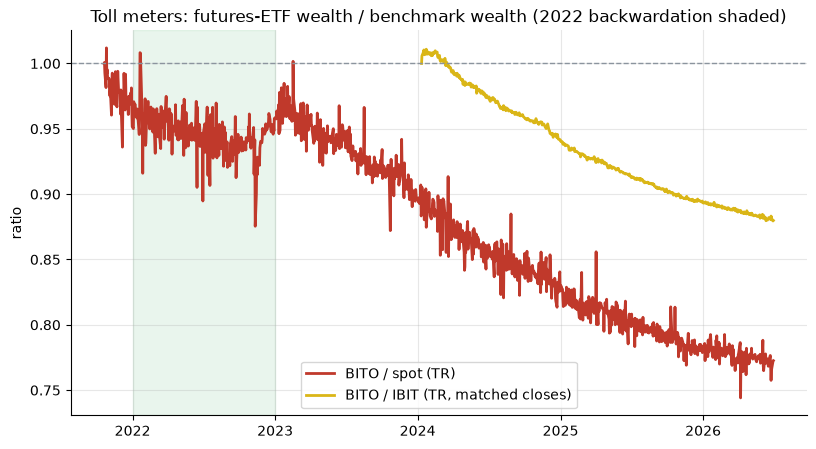

In [4]:
if HAVE_REAL:
    fig, ax = plt.subplots()
    w = F[['spot','bito']]/F[['spot','bito']].iloc[0]
    ax.plot(w.index, w['bito']/w['spot'], color=RED, lw=2, label='BITO / spot (TR)')
    sub = F[['bito','ibit']].dropna(); sub = sub/sub.iloc[0]
    ax.plot(sub.index, sub['bito']/sub['ibit'], color=AMBER, lw=2, label='BITO / IBIT (TR, matched closes)')
    ax.axhline(1, color=GREY, ls='--', lw=1)
    ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), color=GREEN, alpha=.10)
    ax.set_title('Toll meters: futures-ETF wealth / benchmark wealth (2022 backwardation shaded)')
    ax.set_ylabel('ratio'); ax.legend()
    plt.show()
else:
    print('frozen wealth ratios:', R['wealth_ratio'], R['ibit_wealth_ratio'])

## 3 · Roll-window attribution — *where* is the toll paid?

Window = 5 trading days ending on each month's expiry Friday (CME BTC futures terminate the last Friday; BITO rolls into expiry). If the toll were an execution event, the window would carry the shortfall; if it's carry, the bleed is diffuse.

vs spot: in -4.14 bps/d (n=285) | out -0.91 (n=891) | Welch t -0.33 | days 24.2% -> shortfall 54.6%
vs ibit: in -2.84 bps/d (n=150) | out -1.78 (n=467) | Welch t -0.87 | days 24.3% -> shortfall 33.6%


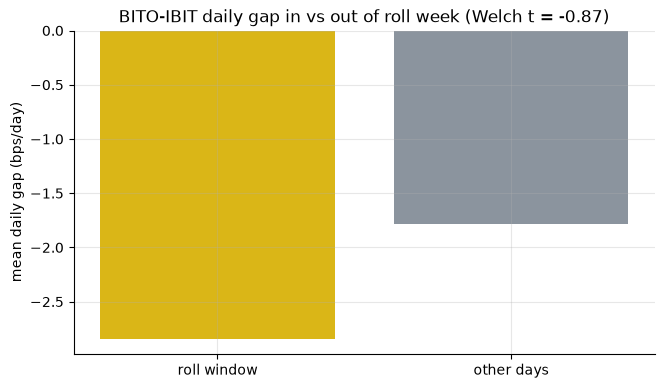

In [5]:
if HAVE_REAL:
    flags = data.roll_window_flags(F.index, width=5)
    for ref in ('spot', 'ibit'):
        ra = st.roll_attribution(F, flags, 'bito', ref)
        print(f"vs {ref:4}: in {ra['in_bps_day']:+.2f} bps/d (n={ra['n_in']}) | out "
              f"{ra['out_bps_day']:+.2f} (n={ra['n_out']}) | Welch t {ra['welch_t']:+.2f} | "
              f"days {ra['share_days']*100:.1f}% -> shortfall {ra['share_shortfall']*100:.1f}%")
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ra = st.roll_attribution(F, flags, 'bito', 'ibit')
    ax.bar(['roll window','other days'], [ra['in_bps_day'], ra['out_bps_day']], color=[AMBER, GREY])
    ax.set_ylabel('mean daily gap (bps/day)')
    ax.set_title(f"BITO-IBIT daily gap in vs out of roll week (Welch t = {ra['welch_t']:+.2f})")
    plt.show()
else:
    for row in R['roll']: print(row)

> 💡 **In plain words:** no toll booth at the roll. The premium melts a little every day; the roll only resets which contract is melting. The folklore's *size* is right, its *location* is wrong — Welch *t* = -0.33 (vs spot) / -0.87 (vs IBIT), nowhere near significance.

## 4 · Contango, backwardation, and the sign of the toll

Front basis = `BTC=F / BTC-USD − 1`. Median **+19.1 bps** at a mean **13.9** days to expiry — **+4.90%/yr annualized**, which is the carry the roll locks in, and it matches the measured beyond-fee drag (~4.44%/yr) almost exactly.

contango share of days: 58.5% | median ann basis +4.90%/yr
2022 median ann basis: -4.72%/yr | 2024-26: +7.16%/yr
2022 gap +33.3 bps/mo vs 2023+ -47.7 bps/mo -> Welch t +0.98


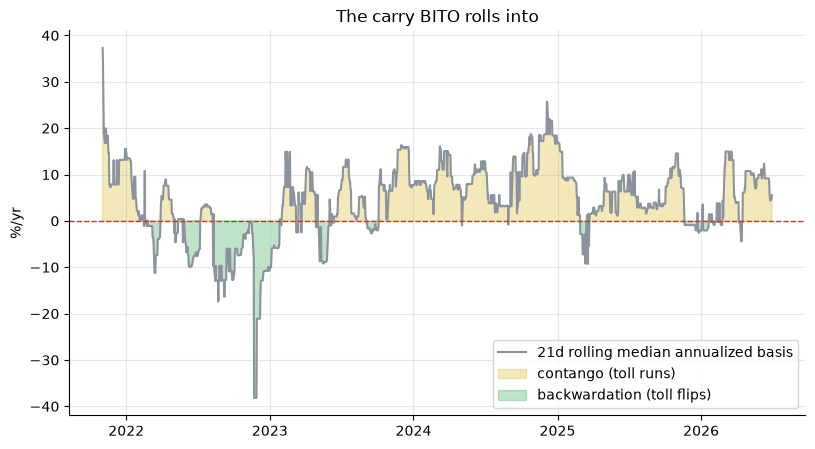

In [6]:
if HAVE_REAL:
    b = st.basis_series(F)
    tau = []
    for d in b.index:
        lf = data.last_friday(d.year, d.month)
        if d > lf:
            nm = d + pd.offsets.MonthBegin(1); lf = data.last_friday(nm.year, nm.month)
        tau.append(max((lf - d).days, 1))
    ann_b = pd.Series(b.values/np.array(tau)*365.0, index=b.index)
    print(f'contango share of days: {(b>0).mean()*100:.1f}% | median ann basis {ann_b.median()*100:+.2f}%/yr')
    print(f'2022 median ann basis: {ann_b[ann_b.index.year==2022].median()*100:+.2f}%/yr | '
          f'2024-26: {ann_b[ann_b.index.year>=2024].median()*100:+.2f}%/yr')
    m = st.monthly_gap(F, 'bito', 'spot'); gap = m['series']
    back, cont = gap[gap.index.year==2022], gap[gap.index.year>=2023]
    w = st.welch_t(back.values, cont.values)
    print(f'2022 gap {back.mean()*1e4:+.1f} bps/mo vs 2023+ {cont.mean()*1e4:+.1f} bps/mo -> Welch t {w["t"]:+.2f}')
    fig, ax = plt.subplots()
    q = ann_b.rolling(21, min_periods=10).median()
    ax.plot(q.index, q*100, color=GREY, lw=1.5, label='21d rolling median annualized basis')
    ax.axhline(0, color=RED, ls='--', lw=1)
    ax.fill_between(q.index, 0, q*100, where=(q>0), color=AMBER, alpha=.3, label='contango (toll runs)')
    ax.fill_between(q.index, 0, q*100, where=(q<=0), color=GREEN, alpha=.3, label='backwardation (toll flips)')
    ax.set_ylabel('%/yr'); ax.set_title('The carry BITO rolls into'); ax.legend()
    plt.show()
else:
    print('frozen: contango share', R['contango_share'], '% | ann basis median', R['ann_basis_median'])

**Attribution honesty.** The year-level contrast is *directionally* the carry story — 2022 (median ann basis -4.7%) saw the gap flip to **+33.3 bps/mo** vs **-47.7** in the contango era — but on 12-vs-42 noisy months it reads Welch *t* = **+0.98**: *suggestive, not certified*. The daily lag-1 basis-sign split (vs IBIT: contango -6.16%/yr vs backwardation -3.35%/yr, Welch *t* = -1.09) is underpowered — and §6 shows that *kind* of split is artifact-prone, so we do not lean on it.

> 💡 **In plain words:** we can prove the toll; proving *statistically* that it runs only when the curve points up needs more backwardation years than bitcoin has given us. The one it did give (2022) behaved exactly as the story predicts.

## 5 · Tradability — harvesting the toll

Long IBIT / short BITO, dollar-neutral, daily rebalance, IBIT era only (before 2024 there was no clean long leg). Short pays borrow on full notional; 2 bps one-way on rebalancing turnover; positions from the prior close.

borrow  0.0%: gross +5.14%/yr -> net +4.90%/yr  HAC t +7.34  Sharpe +2.55
borrow  2.0%: gross +5.14%/yr -> net +2.90%/yr  HAC t +4.34  Sharpe +1.51
borrow  5.0%: gross +5.14%/yr -> net -0.10%/yr  HAC t -0.16  Sharpe -0.05


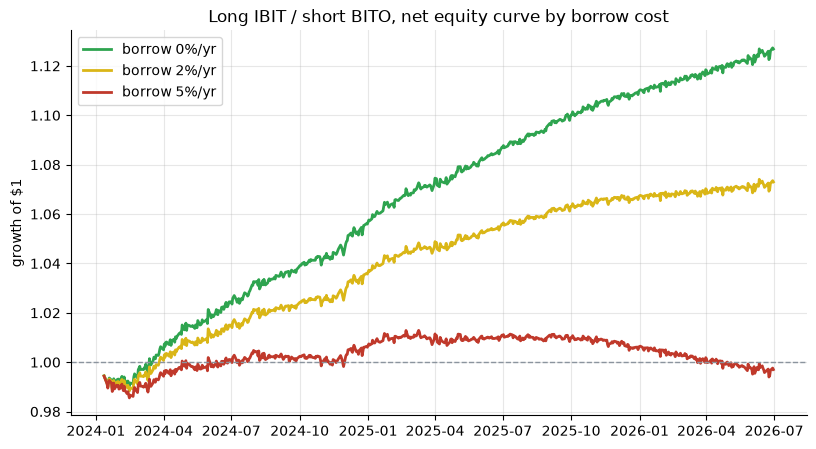

In [7]:
if HAVE_REAL:
    curves = {}
    for borrow in (0.0, 0.02, 0.05):
        sp = st.spread_trade(F, borrow_ann=borrow, cost_bps=2.0)
        print(f"borrow {borrow*100:>4.1f}%: gross {sp['gross_ann_pct']:+.2f}%/yr -> net "
              f"{sp['net_ann_pct']:+.2f}%/yr  HAC t {sp['net_hac_t']:+.2f}  Sharpe {sp['sharpe']:+.2f}")
    sub = F[['ibit','bito']].dropna().pct_change().dropna()
    for borrow, colr in ((0.0, GREEN), (0.02, AMBER), (0.05, RED)):
        net = (sub['ibit']-sub['bito']) - borrow/252 - 2e-4*(sub['ibit'].abs()+sub['bito'].abs())
        curves[borrow] = (1+net).cumprod()
    fig, ax = plt.subplots()
    for borrow, colr in ((0.0, GREEN), (0.02, AMBER), (0.05, RED)):
        ax.plot(curves[borrow].index, curves[borrow], color=colr, lw=2, label=f'borrow {borrow*100:.0f}%/yr')
    ax.axhline(1, color=GREY, ls='--', lw=1)
    ax.set_title('Long IBIT / short BITO, net equity curve by borrow cost')
    ax.set_ylabel('growth of $1'); ax.legend()
    plt.show()
else:
    for row in R['spread']: print(row)

> 💡 **In plain words:** at cheap borrow this is a genuine, low-vol carry (**+2.9%/yr net, Sharpe 1.5**, vol 1.9%, worst day -0.56%). At 5% borrow it's dead (-0.1%/yr). A ~3% absolute carry that lives or dies on the stock-loan desk, on a couple of billion of float, is **Fragile** — and the risk-free version (just *hold the spot ETF*) is cost avoidance, not alpha.

## 6 · Synthetic control — planted basis, faithful machinery *(never market evidence)*

Deterministic GBM spot + front-month curve `F = S·exp(b·τ)` with `b = basis_ann + AR(1) noise`; the futures-ETF NAV rolls at each expiry and pays a fee. Planted drag = basis + fee. The null (basis 0, fee 0) must stay silent.

In [8]:
for basis, fee in ((0.0, 0.0), (0.10, 0.0095)):
    w = data.synthetic_world(basis_ann=basis, fee_ann=fee, seed=619)
    s = st.summarize_drag(w)
    ra = st.roll_attribution(w, data.roll_window_flags(w.index))
    print(f'planted {-(basis+fee)*100:+6.2f}%/yr: measured {s["drag_ann_pct"]:+6.2f}%/yr  '
          f'HAC t {s["hac_t"]:+7.2f}  roll Welch t {ra["welch_t"]:+.2f} (diffuse by construction)')

planted  -0.00%/yr: measured  +0.22%/yr  HAC t   +0.70  roll Welch t +0.20 (diffuse by construction)
planted -10.95%/yr: measured -10.42%/yr  HAC t  -32.55  roll Welch t +0.11 (diffuse by construction)


The detector recovers a planted toll (−10.42 vs −10.95 planted; the residual is calendar-vs-trading-day annualization) and invents nothing from basis noise (null *t* = +0.70). The planted drag is **diffuse across the month by construction** — matching the real tape's roll-window verdict in §3.

**A trap the control exposed:** conditioning the *daily* gap on the lagged basis sign manufactures a large spurious split from mean-reverting basis noise alone (the noise term `τ·Δb` reverses after extreme basis days). That is why §4's regime attribution leans on calendar-year basis levels, not the daily sign flip.

## 7 · Verdict

- **Signal — REAL.** The toll is on the tape twice over: **-34.5 bps/month** vs spot (HAC *t* = -2.32, 70% of months negative, -20.2 pp cumulative) and **-5.14%/yr** vs IBIT on matched closes (HAC(21) *t* = -7.68, lag-robust). Fee gap 0.70% + carry ~4.44% ≈ the +4.90%/yr median annualized front basis: the arithmetic closes. No survivorship (single live instrument).
- **Tradability — FRAGILE.** The active harvest nets **+2.90%/yr (HAC *t* = +4.34, Sharpe 1.51)** at 2% borrow and dies at ~5%; thin, borrow-gated, capacity-bounded. The toll flipped sign in the 2022 backwardation. The passive fix is substitution, not alpha.
- **"Any reason BITO survives?" — BUSTED.** Beta on IBIT = 1.003 — identical exposure — at -5.14%/yr after crediting every distribution; the access and options rationales migrated to the spot ETFs by Nov-2024. Habitat, not performance.

*Mirrors [docs/results.md](../docs/results.md); numbers frozen in `R` (fingerprint `48e3e370f939`). Siblings: [61-slow-burn](../../61-slow-burn/), [100-melting-ice](../../100-melting-ice/), [375-vxx-roll-decay](../../375-vxx-roll-decay/).*